### Deconvolution approach to filter the noise of the data, then measuring the ARI

Summary: Ultimately what we are doing is bringing our noisy data that is in the time domain to the frequency domain and breaking it up into the frequencies that make it up, then we are getting rid of the noisy (high and staggering) frequencies and then inversing the operations to get the non noisy points as the output

Imports

In [94]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
from hdbscan import HDBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from fast_hdbscan.boruvka import sample_weight_core_distance
from scipy.interpolate import interp1d

Dataset

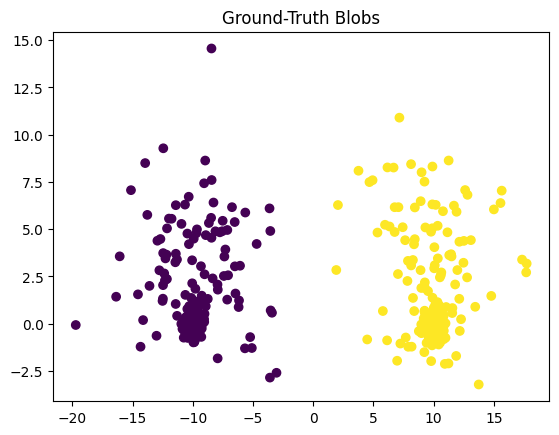

In [127]:
centers = [[-10.0, 0.0], [-10.0, 3.0], [10.0, 0.0], [10.0, 3.0]]
clusters_std = [0.5, 3.0, 0.5, 3.0]

n_per_comp = [100, 100, 100, 100]

X, raw_labels = make_blobs(
    n_samples = n_per_comp,
    centers = centers,
    cluster_std = clusters_std,
    random_state = 42
)

true_labels = raw_labels // 2

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show()

Noisy dataset

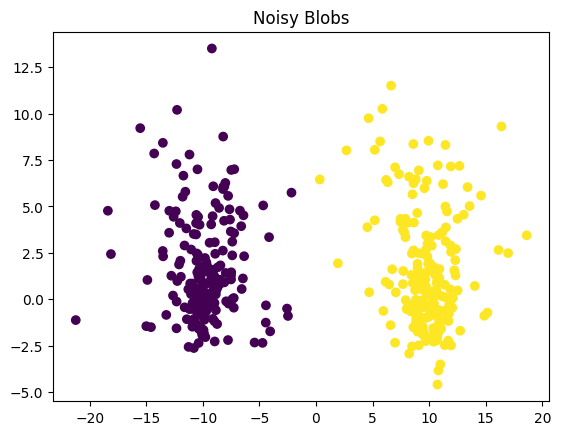

In [128]:
std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="viridis")
plt.title("Noisy Blobs")
plt.show()

Making empirical characteristic function of noisy data 

In [129]:
phi_X = np.mean(np.exp(1j * np.outer(X_obs.flatten(), t)), axis=0) #Computes the empirical characteristic function of all x in X, giving a frequency domain representation of the distribution. Equation: 1/n Sigma n, i=1 (e^i*t*Xi)

phi_U = np.exp(-0.5 * (std**2) * t**2) #Computes the characteristic function for the noise model we use, since we are using gaussian noise the CF we use is e^(-1/2)*var*t^2

### Why do we want to see our distribution in the frequency domain??

The reason we want to see our distribution in the frequency domain is because the frequency domain has special properties, where for example convolution becomes multiplication

Ex: If Y is your true data and U is your noise, your observations are: X = Y + U, where the probabbility densisty function is the convolution of f(y) and f(u)

In the frequency domain X = Y + U is -> $X(t) = $Y(t) * $U(t), so if we know $X(t) and $U(t) where $U(t) is the noise distribution, we can do the opertation $Y(t) = $X(t)/$U(t) to remove the noise. Also reffered to as "Deconvolution"

Kernel window in frequency domain and the grids to evaluate the frequencies

In [ ]:
n = len(X_obs)
sigma_X = np.std(X_obs.flatten())
sigma_U = std
variance_diff = max(sigma_X**2 - sigma_U**2, 1e-8)
c = 1.06 #silverman's constant
h = c * np.sqrt(variance_diff) * n**(-1/5) #Controls how much smoothing is applied to our density estimate, but I do not know how to pick the optimal h, from m research this seemed like the best way to do it (Silverman's rule of thumb adjsuted for deconvolution)

T, N = 1/h, 2**12 #Range of frequencies, number of points in the frequency grid and point grid
t = np.linspace(-T, T, N) #Frequency grid
x_grid = np.linspace(X_obs.min(), X_obs.max(), N) #Grid of observed data points

before_phi_K = (1 - (t*h)**2)**3
phi_K = np.zeros_like(t)
inside = np.abs(t*h) <= 1
phi_K[inside] = (1 - (t[inside]*h)**2)**3 #This computes the fourier transform of the tricube kernel, keeping all the frequencies

Form deconvolution multiplier and inverter

In [135]:
G = phi_X * phi_K / phi_U
fhat = np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(G))).real / (2*np.pi)
fhat /= np.trapz(fhat, x_grid)

/var/folders/v8/5w6w3d096r9c_nw0xsjrrfbm0000gp/T/ipykernel_44095/4008931200.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fhat /= np.trapz(fhat, x_grid)


Interpolate results to allow for arbitrary point selection

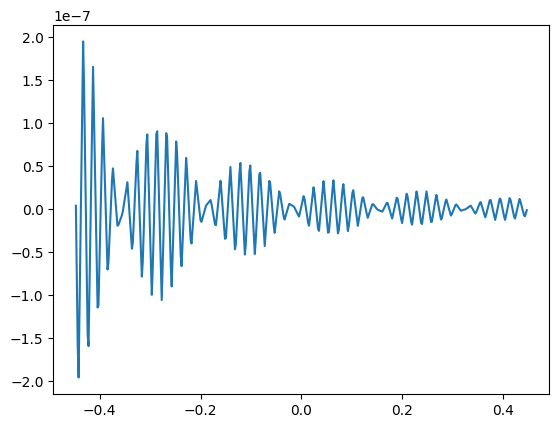

In [136]:
fhat_interp = interp1d(x_grid, fhat, kind="linear", bounds_error=False, fill_value=0.0)

new_x = np.linspace(-T, T, 500)
plt.plot(new_x, fhat_interp(new_x))

Computer core distances

In [137]:
k = 5

X_obs_fixed = X + np.random.normal(scale=std, size=X.shape)

d_obs = np.linalg.norm(
    X_obs_fixed[:, None, :] - X_obs_fixed[None, :, :],
    axis=2
)

core_dist_unc = np.zeros(n)        
for i in range(n):
    dists   = np.linalg.norm(         
        X_obs[i] - X_obs,
        axis=1
    )
    weights = fhat_interp(dists)      
    idx     = np.argsort(dists)       
    cum     = 0.0                     
    for j in idx:                     
        cum += weights[j]             
        if cum >= k:                  
            core_dist_unc[i] = dists[j]  
            break
    else:
        core_dist_unc[i] = dists[idx[-1]]

cd_i = core_dist_unc[:, None]   
cd_j = core_dist_unc[None, :]

assert cd_i.shape == (n, 1) and cd_j.shape == (1, n)

mutual = np.maximum(np.maximum(cd_i, cd_j), d_obs)

clusterer = HDBSCAN(
    metric='precomputed',     
    min_samples=k,
    min_cluster_size=k
)

pred_labels = clusterer.fit_predict(mutual)

ari = adjusted_rand_score(labels_true=true_labels, labels_pred=pred_labels)
print("ARI (uncertainty-aware), variant 4:", ari)

ARI (uncertainty-aware), variant 4: 0.0


### To say:

- After running tests for: Noise level of 1.5 for 2‑component Gaussian mixture with dual‑spread overlays (8 points a part (euclidian distance from mean to mean)), I noticed that HDBSCAN simply with a probability rank matrix can be risky and can sometimes score a very low or very high ARI (but stays around the same on average), but adding our threshold avoids this risk and even when the probabaility rank matrix HDBSCAN performed poorly the threshold probabaility rank amtrix performed well (normally). 
    - In summary: The threshold for the proabbailtiy rank matrix can basically avoid the risk of getting abnormally small or large values, hence it stays around the same more often, but it also gets outperformed often

- Made a list of various datasets we are planning to use, with their real world applications
    -

### Questions:

- Should we use a different kernel? If so, which one?
    - The reason we we picked to use the tricube kernel is because it has a bandwidth cutoff which is good for blocking out noise

- Is the way we are estimating the bandwidth for KDE ok? (Silverman's rule of thumb adjusted for deconvolution (difference between the variance of our data and the variance of our gaussian noise))
    - We do this method because the variance of the noise adds spread to our estimate, so we are "unspreading" the estimate by taking the difference

- Could we get some insights on how to calculate the deconvolution multiplier, inverter, and interpolator?
    - I was thinking 

- Is our understanding of deconvolution correct?
    - From my understanding deconvolution is bringing our noisy data that is in the time domain to the frequency domain and breaking it up into the frequencies that make it up, then we are getting rid of the noisy (high and staggering) frequencies and then inversing the operations to get the non noisy points as the output

- Does deconvolution method relate to the monte carlo probability rank matrix method?? Do they intersect?
    - a

- What types of problems will this project solve in the real world?
    - Medical indsutry, geospatial imaging, etc? 

- What is an interpolator?
    - Estimate of frequency between 2 points? Should we use it and why? 

Fourier transform of a gaussian is a gaussian 

Rreal orld application -> document retreival 

Interpoltion is just filling in the lines

That is step 1 -> finish the fourier divier/multiplier then do some interpolation if necesssaryy

arxiv for math and stuff

Step 2:
- Try to use in 1 dim hdbscn whith 2 gaussians (with a risen valley)
    - You will onlt have the didstanc between points and not the actual position of the points
    - min_cluster size have a theshold that stops sparseclusters (low density) not let the clusrr dm h
    - edit the min_clustrrin the algorithm 
    - (might get reanamed in the code)
    - sklearn signle linkage tree
    - Replace the if statement in min_cluster size where you replafe the sum of 1's by the density of a point
    - the density quals 1/mutual reachiability
- Chets as much as you can with the, 
- Look into fourier transforms with graphs 
- Division. by 0 issue 